# Notebook 01 - Data Cleaning

In [ ]:
#Load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [6]:
DATA_PATH = Path(r"C:\Users\Lenovo\OneDrive\Bureau\Data_portofoliu\Proiect2\telecom-churn-analysis\data\raw_telecom_customer_churn.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.83,-119.00,2,9,NaN,Yes,42.39,No,Yes,Cable,16.00,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.16,-118.20,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.00,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.65,-117.92,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.00,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.01,-122.12,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.00,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.23,-119.08,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.00,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## Initial data inspection

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns:
 {df.shape[1]}")

Rows: 7,043
Columns: 38


In [ ]:
#Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [ ]:
#Descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,7043,7043,0002-ORFBO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,7043.00,NaN,NaN,NaN,46.51,16.75,19.00,32.00,46.00,60.00,80.00
Married,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,7043.00,NaN,NaN,NaN,0.47,0.96,0.00,0.00,0.00,0.00,9.00
City,7043,1106,Los Angeles,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.00,NaN,NaN,NaN,93486.07,1856.77,90001.00,92101.00,93518.00,95329.00,96150.00
Latitude,7043.00,NaN,NaN,NaN,36.20,2.47,32.56,33.99,36.21,38.16,41.96
Longitude,7043.00,NaN,NaN,NaN,-119.76,2.15,-124.30,-121.79,-119.60,-117.97,-114.19
Number of Referrals,7043.00,NaN,NaN,NaN,1.95,3.00,0.00,0.00,0.00,3.00,11.00


In [11]:
#Column names
df.columns.tolist()

['Customer ID',
 'Gender',
 'Age',
 'Married',
 'Number of Dependents',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Customer Status',
 'Churn Category',
 'Churn Reason']

## Data quality checks

In [12]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"] / len(df) * 100
)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Online Backup,1526,21.67
Avg Monthly GB Download,1526,21.67
Online Security,1526,21.67
Streaming Movies,1526,21.67
Streaming TV,1526,21.67
Unlimited Data,1526,21.67
Streaming Music,1526,21.67


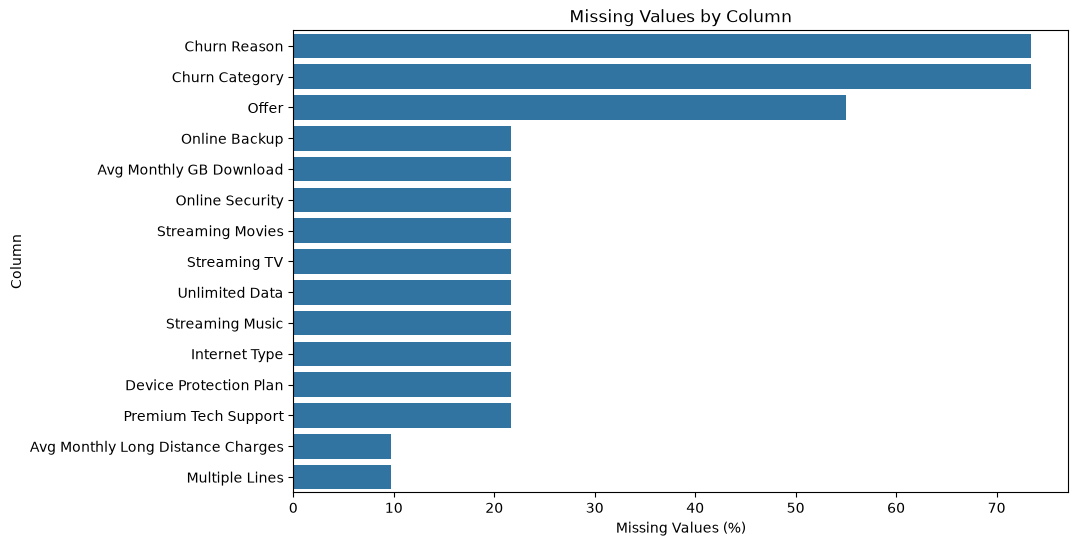

In [13]:
plt.figure(figsize=(10, 6))

missing_nonzero = missing[missing["missing_count"] > 0]

sns.barplot(
    data=missing_nonzero.reset_index(),
    x="missing_pct",
    y="index"
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.show()

In [14]:
#Duplicate customer IDs
df["Customer ID"].duplicated().sum()

np.int64(0)

## Data types

In [15]:
df.dtypes

Customer ID                              str
Gender                                   str
Age                                    int64
Married                                  str
Number of Dependents                   int64
City                                     str
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                    str
Phone Service                            str
Avg Monthly Long Distance Charges    float64
Multiple Lines                           str
Internet Service                         str
Internet Type                            str
Avg Monthly GB Download              float64
Online Security                          str
Online Backup                            str
Device Protection Plan                   str
Premium Tech Support                     str
Streaming 

In [ ]:
#Select categorical and numeric columns
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

Categorical columns:
['Customer ID', 'Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Category', 'Churn Reason']

Numeric columns:
['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']


### Descriptive statistics — numerical variables

In [36]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.00,46.51,16.75,19.00,32.00,46.00,60.00,80.00
Number of Dependents,7043.00,0.47,0.96,0.00,0.00,0.00,0.00,9.00
Zip Code,7043.00,93486.07,1856.77,90001.00,92101.00,93518.00,95329.00,96150.00
Latitude,7043.00,36.20,2.47,32.56,33.99,36.21,38.16,41.96
Longitude,7043.00,-119.76,2.15,-124.30,-121.79,-119.60,-117.97,-114.19
Number of Referrals,7043.00,1.95,3.00,0.00,0.00,0.00,3.00,11.00
Tenure in Months,7043.00,32.39,24.54,1.00,9.00,29.00,55.00,72.00
Avg Monthly Long Distance Charges,6361.00,25.42,14.20,1.01,13.05,25.69,37.68,49.99
Avg Monthly GB Download,5517.00,26.19,19.59,2.00,13.00,21.00,30.00,85.00
Monthly Charge,7043.00,63.60,31.20,-10.00,30.40,70.05,89.75,118.75


### Descriptive statistics — categorical variables

In [37]:
df[categorical_columns].describe().T

,count,unique,top,freq
Customer ID,7043,7043,0002-ORFBO,1
Gender,7043,2,Male,3555
Married,7043,2,No,3641
City,7043,1106,Los Angeles,293
Offer,3166,5,Offer B,824
Phone Service,7043,2,Yes,6361
Multiple Lines,6361,2,No,3390
Internet Service,7043,2,Yes,5517
Internet Type,5517,3,Fiber Optic,3035
Online Security,5517,2,No,3498


In [19]:
#Age validation
df.loc[
    (df["Age"] < 18) | (df["Age"] > 100),
    ["Customer ID", "Age"]
]

,Customer ID,Age


In [20]:
#Tenure validation
df.loc[
    df["Tenure in Months"] < 0,
    ["Customer ID", "Tenure in Months"]
]

,Customer ID,Tenure in Months


In [21]:
#Financial validation
financial_columns = [
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue"
]

df[financial_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly Charge,7043.00,63.60,31.20,-10.00,30.40,70.05,89.75,118.75
Total Charges,7043.00,2280.38,2266.22,18.80,400.15,1394.55,3786.60,8684.80
Total Refunds,7043.00,1.96,7.90,0.00,0.00,0.00,0.00,49.79
Total Extra Data Charges,7043.00,6.86,25.10,0.00,0.00,0.00,0.00,150.00
Total Long Distance Charges,7043.00,749.10,846.66,0.00,70.55,401.44,1191.10,3564.72
Total Revenue,7043.00,3034.38,2865.20,21.36,605.61,2108.64,4801.15,11979.34


### Check number of dependents

In [38]:
dependent_outliers = df[
    df["Number of Dependents"] < 0
]

print(
    f"Negative Number of Dependents: "
    f"{len(dependent_outliers)}"
)

Negative Number of Dependents: 0


### Negative values

In [22]:
negative_monthly_charge = df[
    df["Monthly Charge"] < 0
].copy()

print(f"Negative Monthly Charge values: {len(negative_monthly_charge)}")

negative_monthly_charge[
    ["Customer ID", "Monthly Charge", "Customer Status"]
].sort_values("Monthly Charge")

Negative Monthly Charge values: 120


,Customer ID,Monthly Charge,Customer Status
428,0623-IIHUG,-10.00,Churned
934,1353-LJWEM,-10.00,Stayed
1541,2252-ISRNH,-10.00,Stayed
1407,2077-MPJQO,-10.00,Stayed
3961,5574-NXZIU,-10.00,Stayed
...,...,...,...
5813,8183-ONMXC,-1.00,Churned
6307,8922-LIEGH,-1.00,Churned
6894,9793-WECQC,-1.00,Stayed
6976,9898-KZQDZ,-1.00,Churned


### Investigate negative Monthly Charge values

In [ ]:
#statistics for negative monthly charge values
negative_monthly_charge["Monthly Charge"].describe()

count   120.00
mean     -5.42
std       2.89
min     -10.00
25%      -8.00
50%      -5.00
75%      -3.00
max      -1.00
Name: Monthly Charge, dtype: float64

In [ ]:
#Distribution of negative monthly charge values
negative_monthly_charge[
    "Monthly Charge"
].value_counts().sort_index()

Monthly Charge
-10.00    13
-9.00      9
-8.00     12
-7.00     16
-6.00      6
-5.00     11
-4.00     17
-3.00     13
-2.00     10
-1.00     13
Name: count, dtype: int64

In [ ]:
#Columns for investigation
investigation_columns = [
    "Customer ID",
    "Age",
    "Married",
    "Number of Dependents",
    "City",
    "Tenure in Months",
    "Offer",
    "Phone Service",
    "Internet Service",
    "Internet Type",
    "Contract",
    "Payment Method",
    "Monthly Charge",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "Customer Status",
    "Churn Category",
    "Churn Reason"
]

negative_monthly_charge[
    investigation_columns
].sort_values("Monthly Charge")

,Customer ID,Age,Married,Number of Dependents,City,Tenure in Months,Offer,Phone Service,Internet Service,Internet Type,Contract,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
428,0623-IIHUG,77,No,0,San Diego,21,NaN,No,Yes,Cable,Month-to-Month,Bank Withdrawal,-10.00,840.10,0.00,0,0.00,840.10,Churned,Competitor,Competitor made better offer
934,1353-LJWEM,23,No,0,Cottonwood,11,Offer D,Yes,Yes,DSL,Month-to-Month,Bank Withdrawal,-10.00,688.50,49.24,0,316.36,955.62,Stayed,NaN,NaN
1541,2252-ISRNH,22,Yes,3,Covelo,9,Offer E,Yes,Yes,Fiber Optic,One Year,Bank Withdrawal,-10.00,767.90,0.00,0,274.14,1042.04,Stayed,NaN,NaN
1407,2077-MPJQO,80,Yes,0,Menlo Park,7,NaN,Yes,Yes,Fiber Optic,Month-to-Month,Bank Withdrawal,-10.00,533.05,0.00,0,149.59,682.64,Stayed,NaN,NaN
3961,5574-NXZIU,36,No,0,Los Alamos,63,NaN,Yes,Yes,Fiber Optic,Two Year,Credit Card,-10.00,7049.75,0.00,0,827.82,7877.57,Stayed,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5813,8183-ONMXC,41,No,0,San Diego,2,NaN,Yes,Yes,Fiber Optic,Month-to-Month,Bank Withdrawal,-1.00,159.45,0.00,0,10.22,169.67,Churned,Competitor,Competitor made better offer
6307,8922-LIEGH,72,No,0,Jolon,25,NaN,Yes,Yes,Fiber Optic,Month-to-Month,Bank Withdrawal,-1.00,2187.55,23.33,0,909.00,3073.22,Churned,Dissatisfaction,Poor expertise of online support
6894,9793-WECQC,53,No,0,Foresthill,23,NaN,Yes,Yes,Fiber Optic,Month-to-Month,Credit Card,-1.00,2192.90,0.00,0,1108.83,3301.73,Stayed,NaN,NaN
6976,9898-KZQDZ,65,Yes,0,Lee Vining,40,NaN,Yes,Yes,Fiber Optic,Month-to-Month,Credit Card,-1.00,3640.45,0.00,0,1980.00,5620.45,Churned,Competitor,Competitor had better devices


In [ ]:
#Checking the relationship between negative monthly charge and total refunds
negative_monthly_charge[
    [
        "Customer ID",
        "Monthly Charge",
        "Total Charges",
        "Total Refunds",
        "Total Revenue"
    ]
].sort_values("Total Refunds")

,Customer ID,Monthly Charge,Total Charges,Total Refunds,Total Revenue
32,0052-DCKON,-2.00,7942.15,0.00,10830.97
170,0274-JKUJR,-3.00,465.70,0.00,465.70
232,0361-HJRDX,-8.00,4539.60,0.00,4669.60
336,0495-ZBNGW,-1.00,343.95,0.00,397.25
571,0840-DCNZE,-2.00,4138.90,0.00,5867.56
...,...,...,...,...,...
6236,8818-XYFCQ,-8.00,3204.65,35.82,4353.07
4203,5935-FCCNB,-6.00,1608.15,36.40,2118.98
1,0003-MKNFE,-4.00,542.40,38.33,610.28
6918,9821-BESNZ,-7.00,6860.60,44.00,8995.92


In [ ]:
#Correlation between negative monthly charge and total refunds
negative_monthly_charge[
    [
        "Monthly Charge",
        "Total Refunds",
        "Total Revenue"
    ]
].corr()

,Monthly Charge,Total Refunds,Total Revenue
Monthly Charge,1.00,-0.00,0.02
Total Refunds,-0.00,1.00,0.11
Total Revenue,0.02,0.11,1.00


In [ ]:
#Checking the relationship between negative monthly charge and customer status
negative_monthly_charge[
    "Customer Status"
].value_counts()

Customer Status
Stayed     84
Churned    30
Joined      6
Name: count, dtype: int64

In [29]:
(
    negative_monthly_charge["Customer Status"]
    .eq("Churned")
    .mean()
    * 100
)

np.float64(25.0)

In [ ]:
#Create a new column "Churn Flag" based on the "Customer Status" column
df["Churn Flag"] = (
    df["Customer Status"] == "Churned"
).astype(int)

In [ ]:
#Comparison of customers with negative monthly charges vs. those with non-negative monthly charges
comparison = df.groupby(
    df["Monthly Charge"] < 0
).agg(
    customers=("Customer ID", "count"),
    avg_monthly_charge=("Monthly Charge", "mean"),
    avg_total_revenue=("Total Revenue", "mean"),
    avg_tenure=("Tenure in Months", "mean"),
    churn_rate=("Churn Flag", "mean")
)

comparison["churn_rate"] *= 100

comparison

,customers,avg_monthly_charge,avg_total_revenue,avg_tenure,churn_rate
Monthly Charge,,,,,
False,6923,64.79,3039.70,32.43,26.56
True,120,-5.42,2727.28,29.77,25.00


In [ ]:
#Check whether negative values are simply sign errors
negative_monthly_charge["Abs Monthly Charge"] = (
    negative_monthly_charge["Monthly Charge"].abs()
)

negative_monthly_charge[
    ["Customer ID", "Monthly Charge", "Abs Monthly Charge"]
].sort_values("Monthly Charge")

,Customer ID,Monthly Charge,Abs Monthly Charge
428,0623-IIHUG,-10.00,10.00
934,1353-LJWEM,-10.00,10.00
1541,2252-ISRNH,-10.00,10.00
1407,2077-MPJQO,-10.00,10.00
3961,5574-NXZIU,-10.00,10.00
...,...,...,...
5813,8183-ONMXC,-1.00,1.00
6307,8922-LIEGH,-1.00,1.00
6894,9793-WECQC,-1.00,1.00
6976,9898-KZQDZ,-1.00,1.00


In [39]:
#Revenue consistency check
df["Calculated Revenue"] = (
    df["Total Charges"]
    - df["Total Refunds"]
    + df["Total Extra Data Charges"]
    + df["Total Long Distance Charges"]
)

In [41]:
df["Revenue Difference"] = (
    df["Total Revenue"]
    - df["Calculated Revenue"]
)

In [42]:
df["Revenue Difference"].abs().describe()

count   7043.00
mean       0.00
std        0.00
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        0.00
Name: Revenue Difference, dtype: float64

In [ ]:
#Inconsistencies
revenue_mismatches = df[
    df["Revenue Difference"].abs() > 1
]

print(
    f"Revenue mismatches: "
    f"{len(revenue_mismatches)}"
)

Revenue mismatches: 0


### Check tenure vs total charges

In [44]:
df["Expected Charges"] = (
    df["Monthly Charge"] *
    df["Tenure in Months"]
)

In [45]:
df["Charges Difference"] = (
    df["Total Charges"]
    - df["Expected Charges"]
)

In [46]:
df["Charges Difference"].describe()

count   7043.00
mean      37.65
std      411.99
min     -370.85
25%      -27.75
50%        0.00
75%       31.02
max     8074.15
Name: Charges Difference, dtype: float64

### Check churn-specific fields

In [47]:
churn_missing_reason = df[
    (df["Customer Status"] == "Churned") &
    (
        df["Churn Category"].isna() |
        df["Churn Reason"].isna()
    )
]

print(
    f"Churned customers missing churn information: "
    f"{len(churn_missing_reason)}"
)

Churned customers missing churn information: 0


### Check non-churned customers with churn information

In [48]:
non_churn_with_reason = df[
    (df["Customer Status"] != "Churned") &
    (
        df["Churn Category"].notna() |
        df["Churn Reason"].notna()
    )
]

print(
    f"Non-churned customers with churn information: "
    f"{len(non_churn_with_reason)}"
)

Non-churned customers with churn information: 0


### Check Internet Type consistency

In [49]:
internet_inconsistency = df[
    (df["Internet Service"] == "No") &
    (df["Internet Type"].notna())
]

print(
    f"Internet service inconsistencies: "
    f"{len(internet_inconsistency)}"
)

Internet service inconsistencies: 0


### Check Phone Service vs Multiple Lines

In [50]:
phone_inconsistency = df[
    (df["Phone Service"] == "No") &
    (df["Multiple Lines"] == "Yes")
]

print(
    f"Phone/Multiple Lines inconsistencies: "
    f"{len(phone_inconsistency)}"
)

Phone/Multiple Lines inconsistencies: 0


### Check ZIP codes

In [51]:
invalid_zip = df[
    ~df["Zip Code"].astype(str).str.match(
        r"^\d{5}$",
        na=False
    )
]

print(f"Invalid ZIP codes: {len(invalid_zip)}")

Invalid ZIP codes: 0


### Create cleaned dataset

In [52]:
df_clean = df.copy()

In [53]:
df_clean["Invalid Monthly Charge"] = (
    df_clean["Monthly Charge"] < 0
)

In [54]:
df_clean.loc[
    df_clean["Monthly Charge"] < 0,
    "Monthly Charge"
] = np.nan

In [56]:
#Verify that the negative values have been replaced with NaN
negative_after_cleaning = (
    df_clean["Monthly Charge"] < 0
).sum()

missing_after_cleaning = (
    df_clean["Monthly Charge"].isna()
).sum()

print(
    f"Negative Monthly Charge after cleaning: "
    f"{negative_after_cleaning}"
)

print(
    f"Missing Monthly Charge after cleaning: "
    f"{missing_after_cleaning}"
)

Negative Monthly Charge after cleaning: 0
Missing Monthly Charge after cleaning: 120


In [ ]:
#Check cleaning flag
df_clean["Invalid Monthly Charge"].value_counts()

Invalid Monthly Charge
False    6923
True      120
Name: count, dtype: int64

Verify other financial anomalies

In [59]:
for col in financial_columns:
    count = (
        df_clean[col] < 0
    ).sum()

    print(f"{col}: {count} negative values")

Monthly Charge: 0 negative values
Total Charges: 0 negative values
Total Refunds: 0 negative values
Total Extra Data Charges: 0 negative values
Total Long Distance Charges: 0 negative values
Total Revenue: 0 negative values


### Create analytical dataset

In [71]:
analysis_df = df_clean[
    df_clean["Customer Status"].isin(
        ["Churned", "Stayed"]
    )
].copy()

In [72]:
analysis_df["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Name: count, dtype: int64

Create churn flag in cleaned dataset

In [73]:
analysis_df["Churn Flag"] = (
    analysis_df["Customer Status"] == "Churned"
).astype(int)

In [74]:
analysis_df[
    ["Customer Status", "Churn Flag"]
].value_counts()

Customer Status  Churn Flag
Stayed           0             4720
Churned          1             1869
Name: count, dtype: int64

### Feature engineering — Tenure Segment

In [75]:
analysis_df["Tenure Segment"] = pd.cut(
    analysis_df["Tenure in Months"],
    bins=[-1, 6, 12, 24, 48, np.inf],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49+ months"
    ]
)

### Feature engineering — Age Segment

In [76]:
analysis_df["Age Segment"] = pd.cut(
    analysis_df["Age"],
    bins=[17, 25, 35, 45, 55, 65, np.inf],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

### Feature engineering — Monthly Charge Segment

In [77]:
analysis_df["Monthly Charge Segment"] = pd.cut(
    analysis_df["Monthly Charge"],
    bins=[-np.inf, 40, 80, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

### Feature engineering — Usage Segment

In [78]:
analysis_df["Usage Segment"] = pd.cut(
    analysis_df["Avg Monthly GB Download"],
    bins=[-np.inf, 50, 150, np.inf],
    labels=[
        "Low Usage",
        "Medium Usage",
        "High Usage"
    ]
)

### Check final missing values

In [79]:
final_missing = (
    analysis_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

final_missing["missing_pct"] = (
    final_missing["missing_count"]
    / len(analysis_df)
    * 100
)

final_missing[
    final_missing["missing_count"] > 0
]

,missing_count,missing_pct
Churn Reason,4720,71.63
Churn Category,4720,71.63
Offer,3598,54.61
Online Security,1344,20.40
Streaming Movies,1344,20.40
Streaming TV,1344,20.40
Premium Tech Support,1344,20.40
Usage Segment,1344,20.40
Online Backup,1344,20.40
Internet Type,1344,20.40


In [81]:
#Drop columns that are not needed for analysis
dq_columns = [
    "Calculated Revenue",
    "Revenue Difference",
    "Expected Charges",
    "Charges Difference"
]

analysis_df = analysis_df.drop(
    columns=dq_columns,
    errors="ignore"
)

In [86]:
print("Original dataset:")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

print("\nCleaned dataset:")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]}")

print("\nAnalysis dataset:")
print(f"Rows: {len(analysis_df):,}")
print(f"Columns: {analysis_df.shape[1]}")

Original dataset:
Rows: 7,043
Columns: 43

Cleaned dataset:
Rows: 7,043
Columns: 44

Analysis dataset:
Rows: 6,589
Columns: 44


In [87]:
print("Analysis dataset columns:")
for i, col in enumerate(analysis_df.columns, start=1):
    print(f"{i}. {col}")

Analysis dataset columns:
1. Customer ID
2. Gender
3. Age
4. Married
5. Number of Dependents
6. City
7. Zip Code
8. Latitude
9. Longitude
10. Number of Referrals
11. Tenure in Months
12. Offer
13. Phone Service
14. Avg Monthly Long Distance Charges
15. Multiple Lines
16. Internet Service
17. Internet Type
18. Avg Monthly GB Download
19. Online Security
20. Online Backup
21. Device Protection Plan
22. Premium Tech Support
23. Streaming TV
24. Streaming Movies
25. Streaming Music
26. Unlimited Data
27. Contract
28. Paperless Billing
29. Payment Method
30. Monthly Charge
31. Total Charges
32. Total Refunds
33. Total Extra Data Charges
34. Total Long Distance Charges
35. Total Revenue
36. Customer Status
37. Churn Category
38. Churn Reason
39. Churn Flag
40. Invalid Monthly Charge
41. Tenure Segment
42. Age Segment
43. Monthly Charge Segment
44. Usage Segment


In [89]:
print(
    analysis_df[
        ["Customer Status", "Invalid Monthly Charge"]
    ].head()
)

  Customer Status  Invalid Monthly Charge
0          Stayed                   False
1          Stayed                    True
2         Churned                   False
3         Churned                   False
4         Churned                   False


In [88]:
print(analysis_df['Customer Status'].value_counts())

Customer Status
Stayed     4720
Churned    1869
Name: count, dtype: int64


In [90]:
pd.crosstab(
    analysis_df["Customer Status"],
    analysis_df["Invalid Monthly Charge"]
)

Invalid Monthly Charge,False,True
Customer Status,,
Churned,1839,30
Stayed,4636,84


In [91]:
invalid_charge_summary = (
    analysis_df[
        analysis_df["Invalid Monthly Charge"]
    ]
    .groupby("Customer Status")
    .size()
    .to_frame("customers")
)

invalid_charge_summary

,customers
Customer Status,
Churned,30
Stayed,84
